In [1]:
import pandas as pd

In [2]:
from datetime import datetime
import folium
from folium.plugins import HeatMap
import numpy as np
import seaborn as sns

In [3]:
from sklearn import metrics, preprocessing, tree
import matplotlib.pyplot as plt

In [4]:
#Loading data frame of northern_tss

df = pd.read_excel('Northern.xlsx')

In [5]:
features = df[df['Name'].str.contains('TEMSE', na = False)]

In [6]:
#Loading data frame of southern_tss

df2 = pd.read_excel('Southern.xlsx')

In [7]:
features

,mmsi,shiptype,Length,Breadth,Draught,Longitude,Latitude,SOG,COG,TH,Destination,Name,Callsign,Time
58,205366000,81,142,21,8.2,5.226936,54.04253,15.8,87.5,85,ROSTOCK VIA KIEL,TEMSE,ONCC,2018-02-01 07:23:49.343
59,205366000,81,142,21,8.2,5.246306,54.04346,15.9,85.3,87,ROSTOCK VIA KIEL,TEMSE,ONCC,2018-02-01 07:26:18.877
60,205366000,81,142,21,8.2,5.251626,54.04364,16.1,83.7,86,ROSTOCK VIA KIEL,TEMSE,ONCC,2018-02-01 07:27:00.333
61,205366000,81,142,21,8.2,5.256963,54.04392,16.3,84.7,85,ROSTOCK VIA KIEL,TEMSE,ONCC,2018-02-01 07:27:42.427
62,205366000,81,142,21,8.2,5.272307,54.04465,16.5,85.4,86,ROSTOCK VIA KIEL,TEMSE,ONCC,2018-02-01 07:29:42.627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884995,205366000,81,142,21,8.4,-0.812222,45.36932,13.6,146.9,149,AMBES,TEMSE,ONCC,2018-02-16 16:55:16.077
884996,205366000,81,142,21,8.4,-0.807069,45.36338,13.6,148.7,149,AMBES,TEMSE,ONCC,2018-02-16 16:57:05.933
884997,205366000,81,142,21,8.4,-0.804370,45.36016,13.5,150.2,153,AMBES,TEMSE,ONCC,2018-02-16 16:58:05.910
884998,205366000,81,142,21,8.4,-0.790789,45.33859,13.5,158.0,158,AMBES,TEMSE,ONCC,2018-02-16 17:04:24.350


In [8]:
df2

,mmsi,shiptype,Length,Breadth,Draught,Latitude,Longitude,SOG,COG,TH,Destination,Name,Callsign,time_UTC
0,209792000,71,151,23,8.3,38.42426,-9.000997,10.0,218.5,222,ROTTERDAM,STEFAN SIBUM,5BQX3,2018-01-31 23:08:00.187
1,209792000,71,151,23,8.3,38.42154,-9.003961,11.4,222.4,230,ROTTERDAM,STEFAN SIBUM,5BQX3,2018-01-31 23:09:08.657
2,209792000,71,151,23,8.3,38.41946,-9.007154,12.2,232.8,239,ROTTERDAM,STEFAN SIBUM,5BQX3,2018-01-31 23:10:08.903
3,209792000,71,151,23,8.3,38.41722,-9.011689,13.1,240.3,243,ROTTERDAM,STEFAN SIBUM,5BQX3,2018-01-31 23:11:18.507
4,209792000,71,151,23,8.3,38.41532,-9.016516,14.2,244.7,248,ROTTERDAM,STEFAN SIBUM,5BQX3,2018-01-31 23:12:47.010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,235094449,84,113,20,7.2,47.30369,-2.093795,7.9,271.6,267,BEANR,HAPPY PELICAN,2FUW7,2018-02-06 16:25:19.970
1048571,235094449,84,113,20,7.2,47.30352,-2.097701,8.2,265.1,265,BEANR,HAPPY PELICAN,2FUW7,2018-02-06 16:26:30.180
1048572,235094449,84,113,20,7.2,47.30336,-2.101105,8.4,266.7,266,BEANR,HAPPY PELICAN,2FUW7,2018-02-06 16:27:30.160
1048573,235094449,84,113,20,7.2,47.30322,-2.104562,8.6,265.8,266,BEANR,HAPPY PELICAN,2FUW7,2018-02-06 16:28:40.250


In [9]:
df

,mmsi,shiptype,Length,Breadth,Draught,Longitude,Latitude,SOG,COG,TH,Destination,Name,Callsign,Time
0,205461000,0,0,0,0.0,5.475775,53.94318,16.3,48.0,45,NaN,NaN,NaN,2018-02-01 22:59:53.727
1,205461000,0,0,0,0.0,5.484838,53.94794,16.2,47.0,45,NaN,NaN,NaN,2018-02-01 23:01:29.847
2,205461000,0,0,0,0.0,5.490520,53.95095,16.3,48.0,46,NaN,NaN,NaN,2018-02-01 23:02:30.007
3,205461000,0,0,0,0.0,5.495560,53.95363,16.4,47.4,46,NaN,NaN,NaN,2018-02-01 23:03:23.243
4,205461000,0,0,0,0.0,5.501295,53.95661,16.2,47.0,45,NaN,NaN,NaN,2018-02-01 23:04:23.397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,305677000,79,107,18,5.1,6.369769,53.81753,10.3,325.9,320,ELSA,ROGALAND,V2QM9,2018-02-15 21:25:16.250
1048571,305677000,79,107,18,5.1,6.367003,53.81992,10.5,325.5,321,ELSA,ROGALAND,V2QM9,2018-02-15 21:26:16.217
1048572,305677000,79,107,18,5.1,6.364099,53.82223,10.2,317.6,308,ELSA,ROGALAND,V2QM9,2018-02-15 21:27:16.220
1048573,305677000,79,107,18,5.1,6.360669,53.82413,9.9,308.7,299,ELSA,ROGALAND,V2QM9,2018-02-15 21:28:16.303


In [10]:

m = folium.Map(location=[5.473482,5.394199])

In [11]:
m

In [12]:
df


,mmsi,shiptype,Length,Breadth,Draught,Longitude,Latitude,SOG,COG,TH,Destination,Name,Callsign,Time
0,205461000,0,0,0,0.0,5.475775,53.94318,16.3,48.0,45,NaN,NaN,NaN,2018-02-01 22:59:53.727
1,205461000,0,0,0,0.0,5.484838,53.94794,16.2,47.0,45,NaN,NaN,NaN,2018-02-01 23:01:29.847
2,205461000,0,0,0,0.0,5.490520,53.95095,16.3,48.0,46,NaN,NaN,NaN,2018-02-01 23:02:30.007
3,205461000,0,0,0,0.0,5.495560,53.95363,16.4,47.4,46,NaN,NaN,NaN,2018-02-01 23:03:23.243
4,205461000,0,0,0,0.0,5.501295,53.95661,16.2,47.0,45,NaN,NaN,NaN,2018-02-01 23:04:23.397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,305677000,79,107,18,5.1,6.369769,53.81753,10.3,325.9,320,ELSA,ROGALAND,V2QM9,2018-02-15 21:25:16.250
1048571,305677000,79,107,18,5.1,6.367003,53.81992,10.5,325.5,321,ELSA,ROGALAND,V2QM9,2018-02-15 21:26:16.217
1048572,305677000,79,107,18,5.1,6.364099,53.82223,10.2,317.6,308,ELSA,ROGALAND,V2QM9,2018-02-15 21:27:16.220
1048573,305677000,79,107,18,5.1,6.360669,53.82413,9.9,308.7,299,ELSA,ROGALAND,V2QM9,2018-02-15 21:28:16.303


In [36]:
df.Name.unique()

array([nan, 'VALENTINE', 'TEMSE', 'CLEMENTINE', 'VICTORINE', 'NORFOLK',
       'ANNE SIBUM', 'NORDBAY', 'BOMAR VENUS', 'BLUE STAR',
       'PETUNIA SEAWAYS', 'NEPTUNE DYNAMIS', 'SILVER FREYA',
       'ALICE THERESA', 'CATHY THERESA', 'BRO NIBE', 'SELANDIA SEAWAYS',
       'ANGLIA SEAWAYS', 'BRO NAKSKOV', 'BRO NORDBY', 'BRITANNIA SEAWAYS',
       'SELANDIA SWAN', 'EXPORTER', 'EMMY SCHULTE', 'FIONIA SEAWAYS',
       'JUTLANDIA SEAWAYS', 'PRIGIPOS', 'FURE FERDER', 'FURE WEST',
       'FURE FLADEN', 'CHIBERTA', 'MSC ARICA', 'BESIKTAS ICELAND',
       'PETRA', 'SEELAND', 'UNION VOYAGER', 'TEAL BAY',
       'CAROLINE ESSBERGER', 'BRITISH CUMULUS', 'CLAMOR SCHULTE',
       'ATLANTIC TWIN', 'LOUISE KNUTSEN', 'STENHEIM', 'STEN MOSTER',
       'ZILTBORG', 'STEN IDUN', 'STEN BERGEN', 'ORALYNN', 'ARA LIVERPOOL',
       'LS JAMIE', 'SCELVERINGHE', 'ENERGIZER', 'SCHIEBORG',
       'DUTCH AQUAMARINE', 'VENEZIA D', 'LISA ESSBERGER',
       'CRYSTAL DIAMOND', 'BARBARICA', 'GRANATO', 'SMERALDO', 'CELAND

In [14]:
heat_data = [[row['Latitude'],row['Longitude']] for index, row in features.iterrows()]

In [15]:
HeatMap(heat_data).add_to(m)

In [16]:
m

In [17]:
#Characteristics for northern ships
length = df['Length']
length=length[length!=0]

breadth = df['Breadth']
breadth=breadth[breadth!=0]

draught = df['Draught']
draught=draught[draught!=0]

sog = df['SOG']
sog=sog[sog!=0]

cog = df['COG']
cog=cog[cog!=0]


In [18]:
length

7          162
8          162
9          162
10         162
11         162
          ... 
1048570    107
1048571    107
1048572    107
1048573    107
1048574    107
Name: Length, Length: 998247, dtype: int64

In [19]:
#Characteristics for southern ships
length2 = df2['Length']
length2=length2[length2!=0]

breadth2 = df2['Breadth']
breadth2=breadth2[breadth2!=0]

draught2 = df2['Draught']
draught2=draught2[draught2!=0]

sog2 = df2['SOG']
sog2 = sog2[sog2!=0]

cog2 = df2['COG']
cog2=cog2[cog2!=0]



Text(0.5, 1.0, 'Histogram of Length of Northern and Southern')

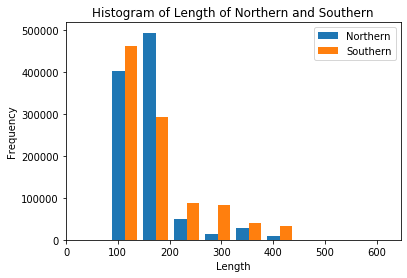

In [20]:
#Plot histogram for Length Comparision
plt.hist([length,length2], label=['Northern','Southern'])
plt.legend()
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.title('Histogram of Length of Northern and Southern')

Text(0.5, 1.0, 'Histogram of Breadth of Northern and Southern')

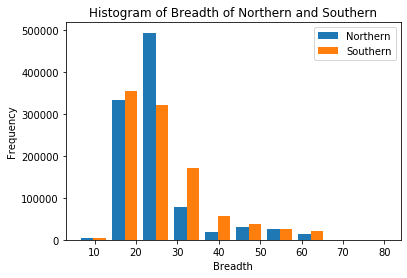

In [21]:
#Plot histogram for Breadth Comparision
plt.hist([breadth,breadth2], label=['Northern','Southern'])
plt.legend()
plt.xlabel('Breadth')
plt.ylabel('Frequency')
plt.title('Histogram of Breadth of Northern and Southern')

Text(0.5, 1.0, 'Histogram of SOG of Northern and southern')

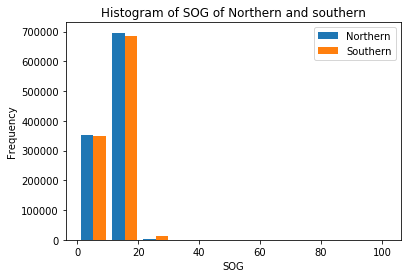

In [22]:
#Plot histogram for Draught Comparision
plt.hist([sog,sog2], label=['Northern','Southern'])
plt.legend()
plt.xlabel('SOG')
plt.ylabel('Frequency')
plt.title('Histogram of SOG of Northern and southern')

Text(0.5, 1.0, 'Histogram of Draught of Northern and southern')

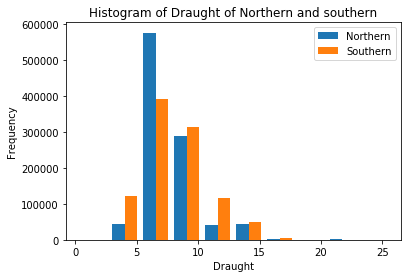

In [23]:
#Plot histogram for Draught Comparision
plt.hist([draught,draught2], label=['Northern','Southern'])
plt.legend()
plt.xlabel('Draught')
plt.ylabel('Frequency')
plt.title('Histogram of Draught of Northern and southern')

Text(0.5, 1.0, 'Histogram of COG of Northern and southern')

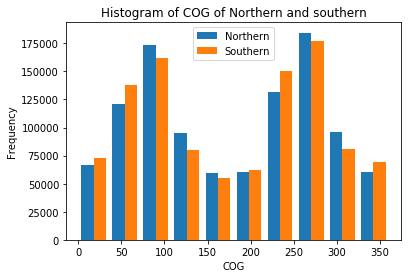

In [24]:
#Plot histogram for COG Comparision
plt.hist([cog,cog2], label=['Northern','Southern'])
plt.legend()
plt.xlabel('COG')
plt.ylabel('Frequency')
plt.title('Histogram of COG of Northern and southern')

In [25]:
length.describe()


count    998247.000000
mean        159.294738
std          55.942001
min          90.000000
25%         127.000000
50%         144.000000
75%         170.000000
max         581.000000
Name: Length, dtype: float64

In [26]:
length2.describe()

count    994851.000000
mean        176.000576
std          76.513193
min          23.000000
25%         120.000000
50%         149.000000
75%         200.000000
max         623.000000
Name: Length, dtype: float64

In [27]:
breadth.describe()

count    998247.000000
mean         24.533780
std           8.512474
min          12.000000
25%          19.000000
50%          23.000000
75%          26.000000
max          60.000000
Name: Breadth, dtype: float64

In [28]:
breadth2.describe()

count    994851.000000
mean         25.982736
std          10.637839
min           6.000000
25%          18.000000
50%          23.000000
75%          32.000000
max          81.000000
Name: Breadth, dtype: float64

In [29]:
draught.describe()

count    997810.000000
mean          7.698692
std           2.303342
min           3.500000
25%           6.300000
50%           7.100000
75%           8.500000
max          25.500000
Name: Draught, dtype: float64

In [30]:
draught2.describe()

count    993601.000000
mean          8.005460
std           2.469429
min           0.200000
25%           6.300000
50%           7.600000
75%           9.200000
max          16.000000
Name: Draught, dtype: float64

In [31]:
sog.describe()

count    1.048575e+06
mean     1.111796e+01
std      4.042380e+00
min      2.000000e-01
25%      9.200000e+00
50%      1.170000e+01
75%      1.360000e+01
max      1.022000e+02
Name: SOG, dtype: float64

In [32]:
sog2.describe()

count    1.048575e+06
mean     1.169820e+01
std      4.619795e+00
min      2.000000e-01
25%      9.100000e+00
50%      1.200000e+01
75%      1.500000e+01
max      7.690000e+01
Name: SOG, dtype: float64

In [33]:
cog.describe()

count    1.047939e+06
mean     1.780887e+02
std      9.953106e+01
min      1.000000e-01
25%      8.280000e+01
50%      1.869000e+02
75%      2.629000e+02
max      3.600000e+02
Name: COG, dtype: float64

In [34]:
cog2.describe()

count    1.048044e+06
mean     1.768150e+02
std      1.009590e+02
min      1.000000e-01
25%      7.720000e+01
50%      1.899000e+02
75%      2.585000e+02
max      3.600000e+02
Name: COG, dtype: float64

In [37]:
jupyter-book build Heatmap/

SyntaxError: invalid syntax (<ipython-input-37-ccb08d9df0eb>, line 1)

In [36]:
jupyter-book build --all Heatmap/

SyntaxError: invalid syntax (<ipython-input-36-677ed59212e7>, line 1)